# 2025 Colorado State University Hackathon Starter Notebook

This notebook will offer an example for loading geospatial data into a potentially desirable format that can be used for completing the challenges.

_________________________________

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.


In [3]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import math
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

2025-03-29 11:00:34.393225: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-29 11:00:34.393299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-29 11:00:34.395134: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-29 11:00:34.404981: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-29 11:00:35.461352: W tensorflow/compiler/tf2

In [4]:
roads_path = "South_Clear_Creek_Roads_Mask.tif"
with rasterio.open(roads_path) as roads_dataset:
    roads_mask = roads_dataset.read(1,masked=True)
    
hillshade_path = "South_Clear_Creek_BareEarth_Hillshade_1m.tif"
with rasterio.open(hillshade_path) as hillshade_dataset:
    # Read in the .tif file as a numpy array
    hillshade = hillshade_dataset.read(1,masked=True)

DEM_path = "South_Clear_Creek_BareEarth_DEM_1m.tif"
with rasterio.open(DEM_path) as DEM_dataset:
    # Read in the .tif file as a numpy array
    DEM = DEM_dataset.read()
'''
NAIP_06m_path = "South_Clear_Creek_2023_NAIP_06m.tif"
with rasterio.open(NAIP_06m_path) as NAIP_06m_dataset:
    # Read in the .tif file as a numpy array
    NAIP_06m = NAIP_06m_dataset.read()

NAIP_1m_path = "South_Clear_Creek_2023_NAIP_1m.tif"
with rasterio.open(NAIP_1m_path) as NAIP_1m_dataset:
    # Read in the .tif file as a numpy array
    NAIP_1m = NAIP_1m_dataset.read()
'''

'\nNAIP_06m_path = "South_Clear_Creek_2023_NAIP_06m.tif"\nwith rasterio.open(NAIP_06m_path) as NAIP_06m_dataset:\n    # Read in the .tif file as a numpy array\n    NAIP_06m = NAIP_06m_dataset.read()\n\nNAIP_1m_path = "South_Clear_Creek_2023_NAIP_1m.tif"\nwith rasterio.open(NAIP_1m_path) as NAIP_1m_dataset:\n    # Read in the .tif file as a numpy array\n    NAIP_1m = NAIP_1m_dataset.read()\n'

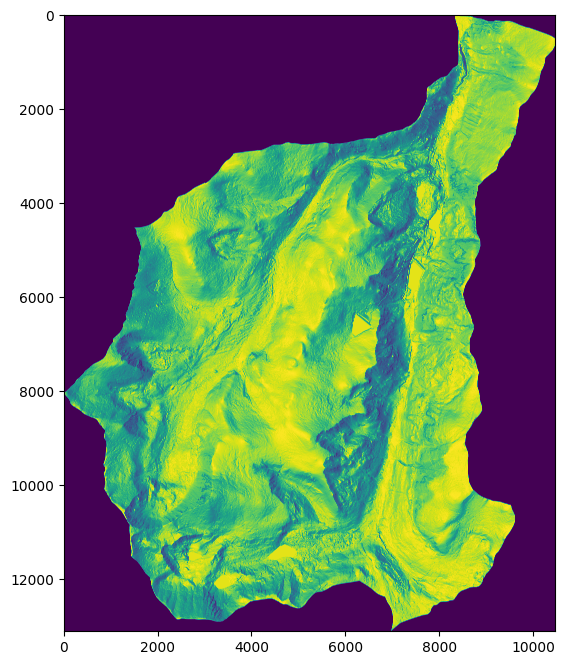

In [5]:
# View an image of the entire array
plt.figure(figsize=(8, 8))
plt.imshow(hillshade)
plt.show()

In [6]:
num = np.float128(1.5) * 10 ** np.float128(38)
print(num)

DEMUpdated = np.where(DEM > num, 0, DEM)
DEMUpdated = np.where(DEMUpdated < 2700, 0, DEM)

1.5e+38


In [7]:
DEMUpdatedNormalized = (DEMUpdated - 2700) / (4100 - 2700)

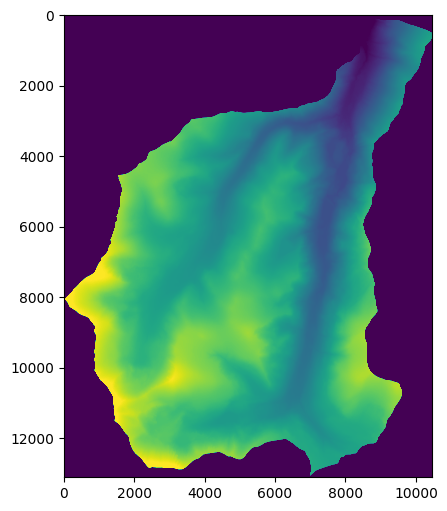

In [8]:
# View an image of the entire array
plt.figure(figsize=(6, 6))
plt.imshow(DEMUpdatedNormalized.transpose(1, 2, 0), vmin=0, vmax=1)
plt.show()

In [35]:
DEMSubImages = np.zeros((308, 256, 256))
RoadSubImages = np.zeros((308, 256, 256))
HillShadeImages = np.zeros((308, 256, 256))
Index = -1
for n in range(0, 12800, 256):
  for l in range(0, 10240, 256):
      if(np.max(roads_mask[n:(n+256),l:(l+256)]) == 1):
          Index = Index + 1
          DEMSubImages[Index] = DEMUpdatedNormalized[0,n:(n+256),l:(l+256)]
          RoadSubImages[Index] = roads_mask[n:(n+256),l:(l+256)]
          HillShadeImages[Index] = hillshade[n:(n+256),l:(l+256)]

In [27]:
np.nanpercentile(NAIP_1m_mask, 99)

NameError: name 'NAIP_1m_mask' is not defined

In [ ]:
NAIP_1m_mask = np.where(DEM > np.nanpercentile(NAIP_1m_mask, 99), 0, DEM)

In [ ]:
# View an image of the entire array
plt.figure(figsize=(6, 6))
plt.imshow(NAIP_1m_mask.transpose(1, 2, 0), vmin=0, vmax=1)
plt.show()

In [38]:
inputImages = np.zeros((308, 256, 256, 2))
for n in range(308):
    inputImages[n,:,:,0] = hillshade[n:(n+256),l:(l+256)]
    inputImages[n,:,:,1] = DEMUpdatedNormalized[0,n:(n+256),l:(l+256)]

In [75]:
class Denoise(Model):
  def __init__(self):
    super(Denoise, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Input(shape=(256, 256, 2)),
      layers.Conv2D(64, 1, activation='relu', padding='same', strides=2),
      layers.Conv2D(32, 1, activation='relu', padding='same', strides=2)])

    self.decoder = tf.keras.Sequential([
      layers.Conv2DTranspose(32, kernel_size=1, strides=2, activation='relu', padding='same'),
      layers.Conv2DTranspose(64, kernel_size=1, strides=2, activation='relu', padding='same'),
      layers.Conv2DTranspose(1, kernel_size=1, activation='relu', padding='same')])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = Denoise()

In [72]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [65]:
autoencoder.fit(inputImages, RoadSubImages,
                epochs=100,
                shuffle=True)

Epoch 1/100
10/10 [==============================] - 3s 101ms/step - loss: 0.0596
Epoch 2/100
10/10 [==============================] - 1s 55ms/step - loss: 0.0049
Epoch 3/100
10/10 [==============================] - 1s 55ms/step - loss: 0.0049
Epoch 4/100
10/10 [==============================] - 1s 55ms/step - loss: 0.0049
Epoch 5/100
10/10 [==============================] - 1s 55ms/step - loss: 0.0049
Epoch 6/100
10/10 [==============================] - 1s 54ms/step - loss: 0.0049
Epoch 7/100
10/10 [==============================] - 1s 54ms/step - loss: 0.0049
Epoch 8/100
10/10 [==============================] - 1s 53ms/step - loss: 0.0049
Epoch 9/100
10/10 [==============================] - 1s 54ms/step - loss: 0.0049
Epoch 10/100
10/10 [==============================] - 1s 54ms/step - loss: 0.0049
Epoch 11/100
10/10 [==============================] - 1s 54ms/step - loss: 0.0049
Epoch 12/100
10/10 [==============================] - 1s 54ms/step - loss: 0.0049
Epoch 13/100
10/10 [====

In [73]:
encoded_imgs = autoencoder.encoder(inputImages).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

2025-03-29 11:27:51.277739: W external/local_tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.20GiB (rounded to 1291845632)requested by op Conv2D
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-03-29 11:27:51.277805: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2025-03-29 11:27:51.277821: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 140, Chunks in use: 140. 35.0KiB allocated for chunks. 35.0KiB in use in bin. 7.8KiB client-requested in use in bin.
2025-03-29 11:27:51.277830: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 11, Chunks in use: 11. 6.8KiB allocated for chunks. 6.8KiB in use in bin. 5.8KiB client-requested in use in bin.
2025-03-29 11:27:51.2778

ResourceExhaustedError: Exception encountered when calling layer 'conv2d_21' (type Conv2D).

{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[308,64,128,128] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:Conv2D] name: 

Call arguments received by layer 'conv2d_21' (type Conv2D):
  • inputs=tf.Tensor(shape=(308, 256, 256, 2), dtype=float32)

In [ ]:
decoded_imgs.shape

In [ ]:
plt.imshow(decoded_imgs[22])

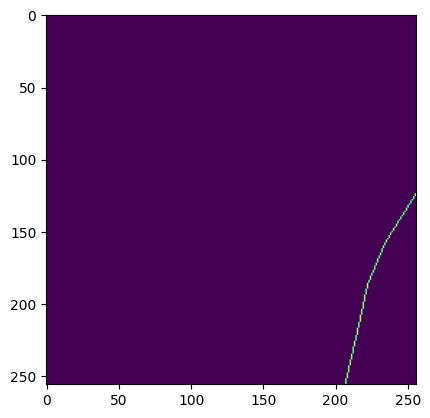

In [56]:
plt.imshow(RoadSubImages[22])

In [ ]:
recreatedImage = np.zeros((12800, 10240))
Index = -1
for n in range(0, 12800, 256):
  for l in range(0, 10240, 256):
      Index = Index + 1
      recreatedImage[n:(n+256),l:(l+256)] = decoded_imgs[Index,:,:,0]

In [ ]:
plt.figure(figsize=(8, 8)) 
plt.imshow(recreatedImage)

In [ ]:
plt.imshow(decoded_imgs[1005])

model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(28, 28, 1)),
    keras.layers.Reshape(target_shape=(28, 28, 1)),
    keras.layers.Conv2D(kernel_size=3, filters=2, activation='relu', padding='same', input_shape=(28, 28, 1)),
    keras.layers.Activation('relu'),

    keras.layers.Conv2D(kernel_size=6, filters=24, activation='relu', padding='same', strides=2),
    keras.layers.Activation('relu'),

    keras.layers.Conv2D(kernel_size=6, filters=32, activation='relu', padding='same', strides=2),
    keras.layers.Activation('relu'),

    keras.layers.Flatten(),

    keras.layers.Dense(200, use_bias=False),
    keras.layers.BatchNormalization(center=True, scale=False),
    keras.layers.Activation('relu'),

    keras.layers.Dropout(0.3),
    keras.layers.Dense(25, activation = tf.nn.softmax)
])